# Day 3: Customer Segmentation (K-Means / DBSCAN)

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from src.models.segmentation import prepare_features, sweep_kmeans_k, sweep_dbscan_eps, fit_kmeans, label_segments,write_segments

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

rfm = pd.read_csv("../data/features/rfm.csv").set_index("customer_id")
X, scaler = prepare_features(rfm)
rfm.shape

(5852, 7)

## Why log-transform before clustering

Frequency and monetary are heavily right-skewed (skew 12.0 and 25.6
respectively; recency is much milder at 0.9). K-Means measures distance in
raw Euclidean space, so a handful of high-spend wholesale customers would
otherwise dominate every cluster assignment.

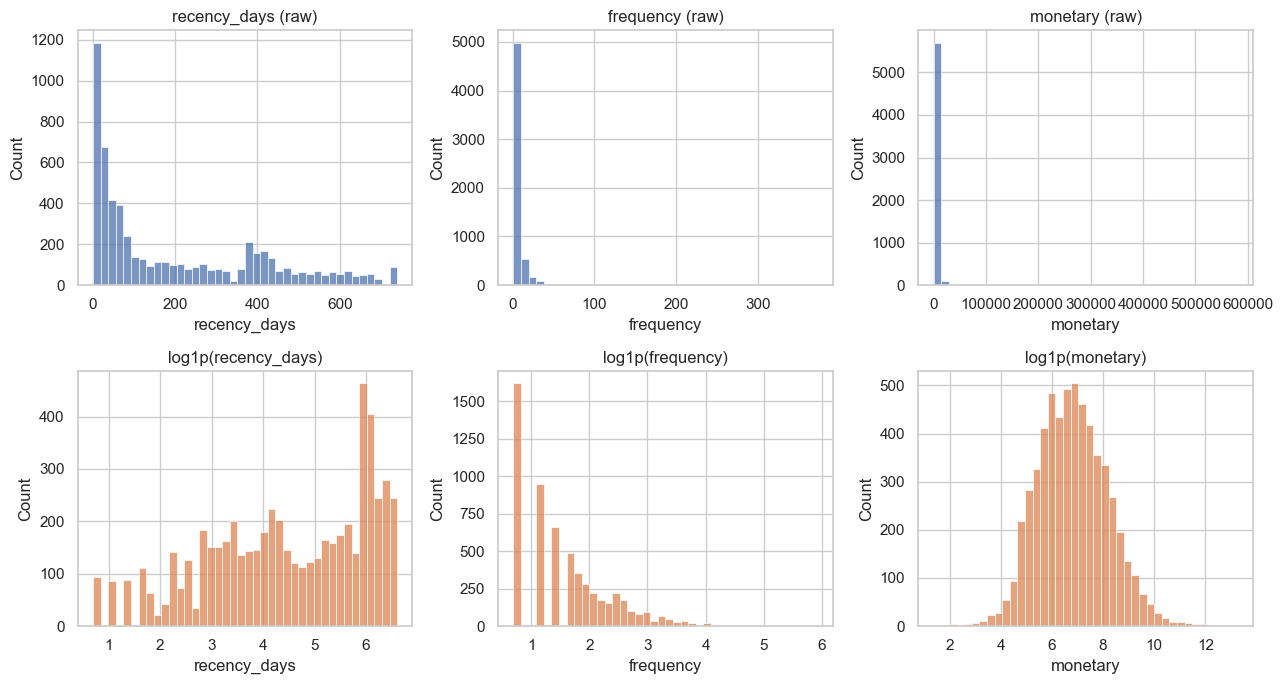

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for i, col in enumerate(["recency_days", "frequency", "monetary"]):
    sns.histplot(rfm[col], bins=40, ax=axes[0, i], color="#4C72B0")
    axes[0, i].set_title(f"{col} (raw)")
    sns.histplot(np.log1p(rfm[col]), bins=40, ax=axes[1, i], color="#DD8452")
    axes[1, i].set_title(f"log1p({col})")
plt.tight_layout()
plt.show()

## K-Means: choosing k

In [5]:
kmeans_sweep = sweep_kmeans_k(X, k_range=range(2, 13))
kmeans_sweep

,inertia,silhouette,davies_bouldin
k,,,
2,8561.593369,0.438293,0.873816
3,6337.654352,0.347082,1.037093
4,4907.534454,0.365131,0.931048
5,4090.112000,0.342549,0.949693
6,3549.373714,0.335108,0.962190
7,3182.079160,0.302769,0.984145
8,2892.127364,0.295280,0.989955
9,2650.230304,0.289410,1.014615
10,2460.210114,0.288657,1.020520


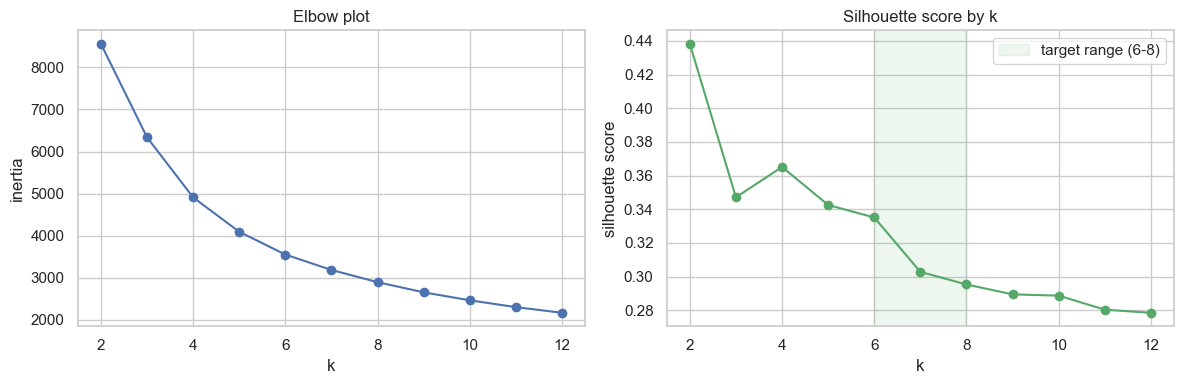

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(kmeans_sweep.index, kmeans_sweep["inertia"], marker="o", color="#4C72B0")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[0].set_title("Elbow plot")

axes[1].plot(kmeans_sweep.index, kmeans_sweep["silhouette"], marker="o", color="#55A868")
axes[1].axvspan(6, 8, color="#55A868", alpha=0.1, label="target range (6-8)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette score by k")
axes[1].legend()

plt.tight_layout()
plt.show()

The elbow plot doesn't show one obviously "correct" k, which is normal for
RFM data: customer behavior is a continuum, not naturally clustered. The
silhouette curve picks k=6 as the best-scoring option inside the 6-8 target
range.

## DBSCAN

In [7]:
eps_range = np.arange(0.2, 2.01, 0.1)
dbscan_sweep = sweep_dbscan_eps(X, eps_range, min_samples=10)
dbscan_sweep

,n_clusters,n_noise,noise_pct,silhouette
eps,,,,
0.2,11,1218,20.813397,0.039049
0.3,3,370,6.322625,0.165115
0.4,2,149,2.546138,0.280314
0.5,2,83,1.418319,0.277756
0.6,1,50,0.854409,NaN
0.7,1,38,0.649351,NaN
0.8,1,23,0.393028,NaN
0.9,1,15,0.256323,NaN
1.0,1,8,0.136705,NaN


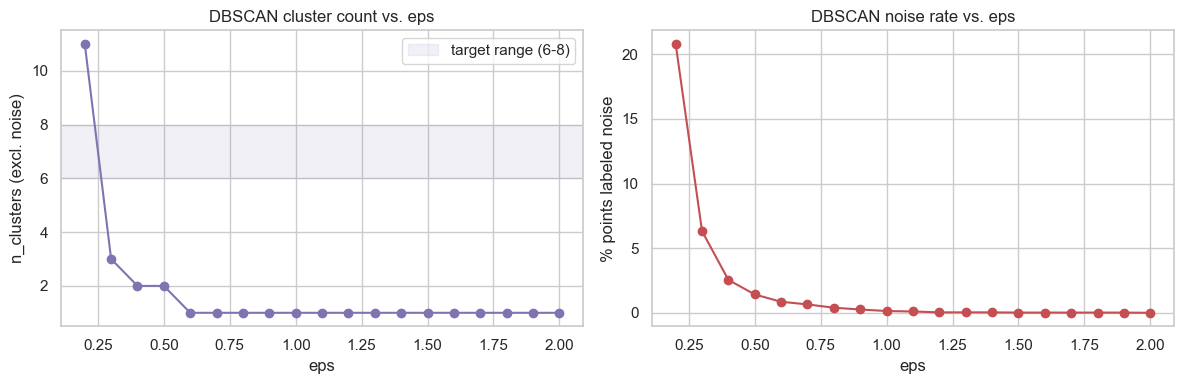

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(dbscan_sweep.index, dbscan_sweep["n_clusters"], marker="o", color="#8172B2")
axes[0].axhspan(6, 8, color="#8172B2", alpha=0.1, label="target range (6-8)")
axes[0].set_xlabel("eps")
axes[0].set_ylabel("n_clusters (excl. noise)")
axes[0].set_title("DBSCAN cluster count vs. eps")
axes[0].legend()

axes[1].plot(dbscan_sweep.index, dbscan_sweep["noise_pct"], marker="o", color="#C44E52")
axes[1].set_xlabel("eps")
axes[1].set_ylabel("% points labeled noise")
axes[1].set_title("DBSCAN noise rate vs. eps")

plt.tight_layout()
plt.show()

DBSCAN's cluster count drops sharply as eps increases: small eps produces
dozens of tiny clusters plus heavy noise, and by the eps where noise
becomes manageable, the data has already collapsed to 1-2 clusters. There's
no eps where it lands at 6-8. This is finding about the data's
density structure, not a tuning failure: RFM space here doesn't have
density gaps that match the business's desired granularity. K-Means, which
imposes a partition rather than discovering density gaps, is the
appropriate choice for this requirement.

## Final segmentation

In [9]:
model = fit_kmeans(X, k=6)
segmented = label_segments(rfm, model.labels_)
segment_profile = segmented.groupby("segment_name")[["recency_days", "frequency", "monetary"]].agg(["mean", "count"])
write_segments(segmented)
segment_profile

2026-06-20 19:42:19,981 [INFO] Wrote 5852 customer rows to D:\retailplus\data\features\customer_segments.csv


recency_days        frequency            monetary      
                           mean count       mean count          mean count
segment_name                                                              
at_risk_high_value    88.523026   912  10.155702   912   4416.942248   912
champions_core        16.422892   830   5.532530   830   1704.169265   830
champions_premium     11.868644   472  31.385593   472  19661.732458   472
lost_core            438.265806  1471   1.232495  1471    251.507213  1471
lost_premium         296.746942  1308   3.477064  1308   1214.556514  1308
new_or_occasional     45.121071   859   1.821886   859    450.437893   859

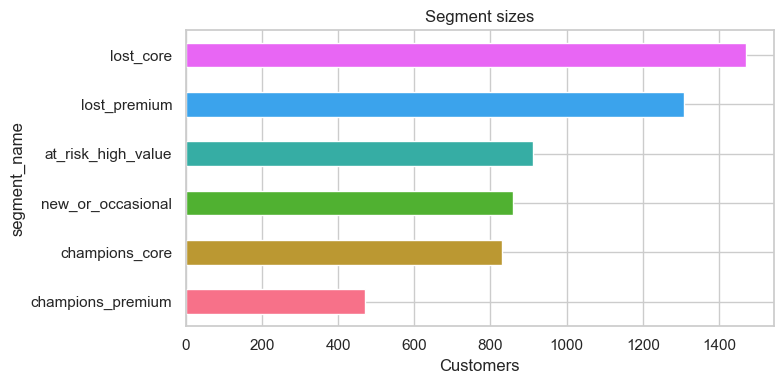

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sizes = segmented["segment_name"].value_counts().sort_values()
sizes.plot(kind="barh", ax=ax, color=sns.color_palette("husl", len(sizes)))
ax.set_xlabel("Customers")
ax.set_title("Segment sizes")
plt.tight_layout()
plt.show()

### 2D projection 

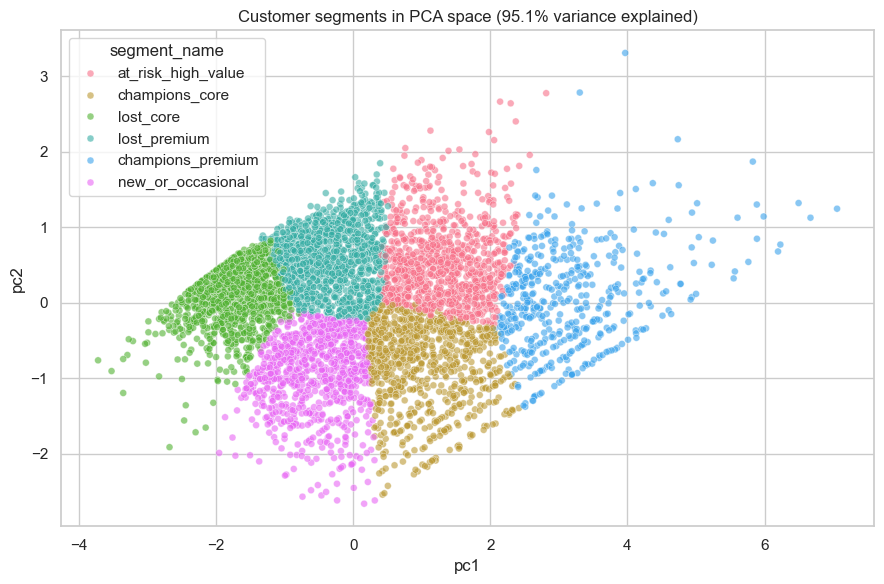

In [11]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)
plot_df = pd.DataFrame(coords, columns=["pc1", "pc2"], index=rfm.index)
plot_df["segment_name"] = segmented["segment_name"].values

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=plot_df, x="pc1", y="pc2", hue="segment_name", palette="husl", alpha=0.6, s=25, ax=ax)
ax.set_title(f"Customer segments in PCA space ({pca.explained_variance_ratio_.sum()*100:.1f}% variance explained)")
plt.tight_layout()
plt.show()

## Day 3 findings summary

- K-Means with k=6 is the chosen segmentation: silhouette 0.337, the
  best score inside the spec's 6-8 segment target range.
- Naming required a real fix mid-build: the first version compared each
  cluster's mean to the *population* mean, which is skewed by a handful of
  huge-spend customers, and collapsed 6 statistically distinct clusters
  into 3 visible names. Fixed by ranking clusters against each other
  (median of cluster-level means) and disambiguating any remaining ties
  with a monetary-based qualifier, so all 6 clusters now have distinct,
  interpretable names: `champions_premium`, `champions_core`,
  `at_risk_high_value`, `lost_premium`, `lost_core`, `new_or_occasional`.
- `champions_premium` (459 customers) carries disproportionate revenue
  weight (mean monetary ~£20K vs. the overall population mean of ~£3K) and
  is the clearest candidate for a dedicated retention strategy.